In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import gdown
import re
import os
import pandas as pd
import seaborn as sns
import scvi
import gc
import scipy as sp
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from cell2location.utils.filtering import filter_genes

def colour_tables(feature_series):
    features = list(set(feature_series))
    hex_features = []
    for i in range(len(features)):
        r = np.random.randint(0,200)
        g = np.random.randint(0,200)
        b = np.random.randint(0,200)
        colour = '#{:02x}{:02x}{:02x}'.format(r, g, b)
        hex_features.append(colour)
    return hex_features

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/requests/__init__.py:104: RequestsDependencyWarning: urllib3 (1.26.8) or chardet (5.1.0)/charset_normalizer (2.0.11) doesn't match a supported version!
  RequestsDependencyWarning)
Global seed set to 0
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/pytorch_lightning/utilities/warnings.py:54: LightningDeprecationWarning: pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6 and will be removed in v1.8. Use the equivalent function from the pytorch_lightning.utilities.rank_zero module instead.
  "pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6"
/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/pytorch_lightning/utilities/warnings.py:58: LightningDeprecationWarning: The `pytorch_lightning.loggers.base.rank_zero_experiment` is deprecated in v1.7 and will be removed in

In [ ]:
import cell2location 

# Load and prepare adata

In [ ]:
# Read donor metadata
sample_summary = pd.read_csv('../data/samplelist_phase_one_v2.txt', sep='\t')

In [ ]:
# Load data
adata = sc.read_h5ad('../data/adata/GBM_LEAP_23_05_15_MAD.h5ad')

In [ ]:
adata.X = adata.layers['counts'].copy()

# Run setup

In [ ]:
out_dir = '../data/scVI_embeddings/final/'

In [ ]:
data_name = '15_05_2023'

# SCVI integration

In [ ]:
adata.raw = adata

## cell2loc HVG selection

/nfs/team283/gd11/software/miniconda3/envs/scarches_new/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


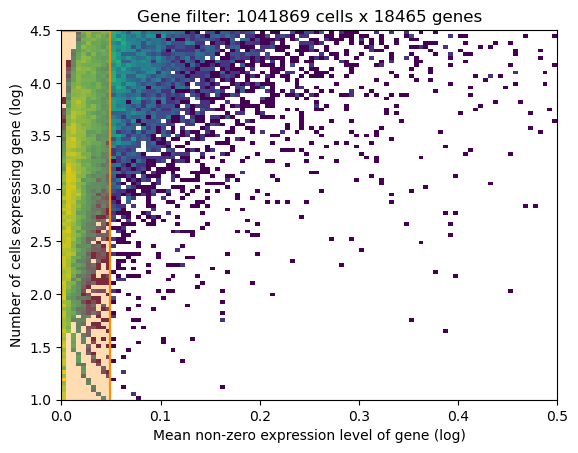

In [ ]:
## Filter genes on the basis patient expression
selected_c2l = filter_genes(adata, cell_count_cutoff=5, 
                            cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

## Batch-aware HVG selection

In [ ]:
# i.e. scanpy/seurat methods
# check if count matrix is normalised (e.g. via adata[:,adata.var['SYMBOL']=='MALAT1'].X.toarray())

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
sc.pp.highly_variable_genes(adata, 
                            min_mean=0.0075, 
                            max_mean=4, 
                            min_disp=0.1,
                            batch_key="donor_id"
)

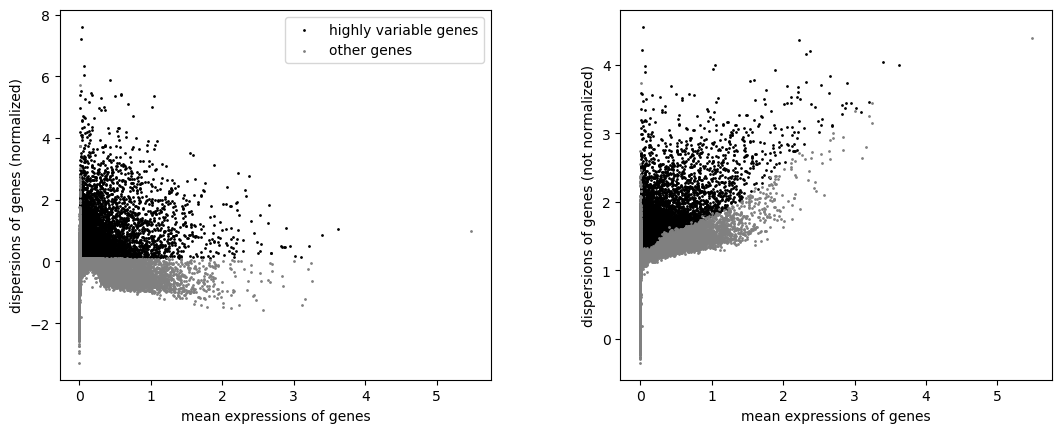

In [ ]:
sc.pl.highly_variable_genes(adata)

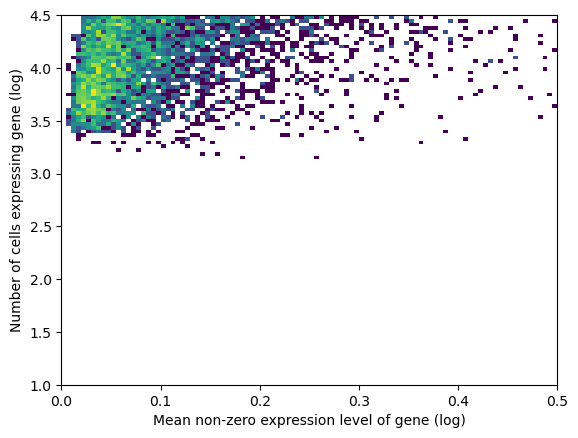

In [ ]:
fig, ax = plt.subplots()
ax.hist2d(
        np.log10(adata[:,adata.var['highly_variable']==True].var["nonz_mean"]),
        np.log10(adata[:,adata.var['highly_variable']==True].var["n_cells"]),
        bins=100,
        norm=mpl.colors.LogNorm(),
        range=[[0, 0.5], [1, 4.5]],
    )

plt.xlabel("Mean non-zero expression level of gene (log)")
plt.ylabel("Number of cells expressing gene (log)")
plt.show()

In [ ]:
selected = adata.var['highly_variable']

## Filter gene selection

In [ ]:
adata = adata[:, selected].copy()

# scVI integration

In [ ]:
# check the UMAP without phase as a covariate
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key = "sample",
    categorical_covariate_keys=["date", "donor_id", "site_id", 'phase']
)

In [ ]:
model = scvi.model.SCVI(adata,
                       n_hidden = 1024,
                       n_layers = 2,
                       n_latent = 50,
                       gene_likelihood = 'nb',
                       dispersion = 'gene-batch',
                       use_observed_lib_size = True)
model.train(train_size=0.99, max_epochs=200, batch_size = 1024) #max_epochs=200, 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 28/200:  14%|███████▋                                                 | 27/200 [25:20<2:47:38, 58.14s/it, loss=2.81e+03, v_num=1]

In [ ]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent

In [ ]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.leiden(adata, key_added="leiden_scVI")
sc.tl.umap(adata, min_dist=0.3)

In [ ]:
adata.write_h5ad('../data/adata/')

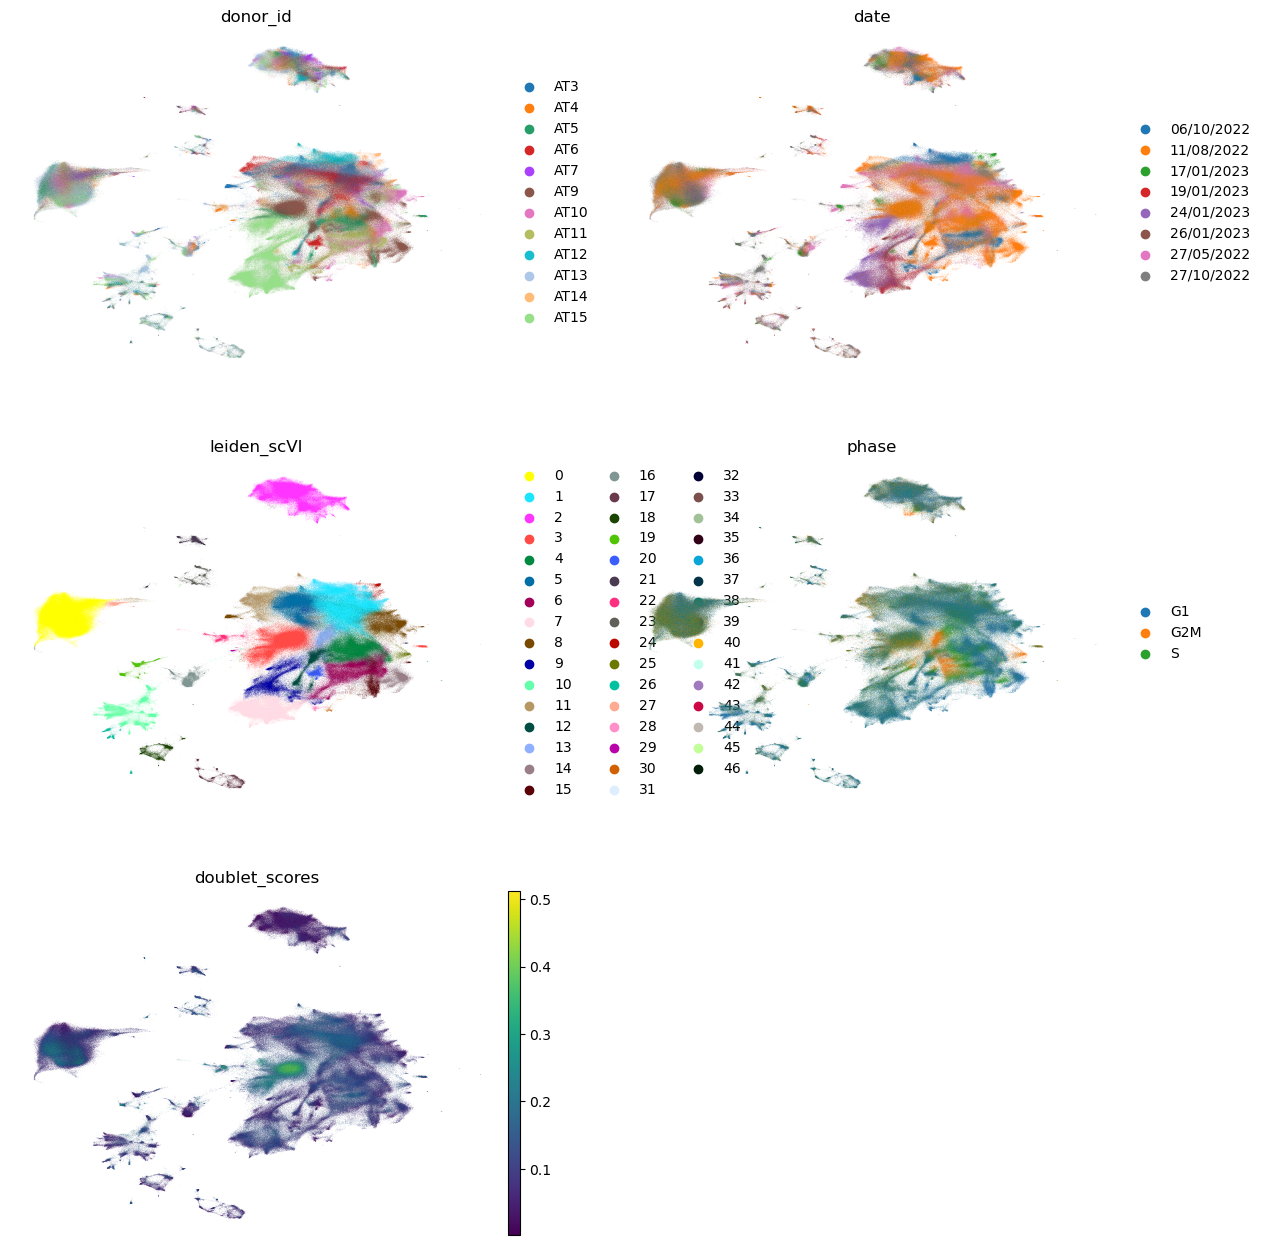

In [ ]:
# generate UMAP
sc.pl.umap(
    adata,
    color=["donor_id", "date", "leiden_scVI", "phase", "doublet_scores"],
    ncols=2,
    size=0.1,
    save = '_scVI_test_{}.png'.format(data_name),
    frameon=False)

In [ ]:
# embeddings
np.save(out_dir+'embeddings_{}.npy'.format(data_name), adata.obsm['X_scVI'])

# cluster membership
per_cluster = adata.obs.groupby(['donor_id', 'leiden_scVI'], as_index=False)['cell_id'].count()
per_cluster = per_cluster.pivot(index='donor_id', columns='leiden_scVI', values='cell_id')
per_cluster.to_csv(out_dir+'per_cluster_membership_{}.csv'.format(data_name))

## Evaluate QC metrics

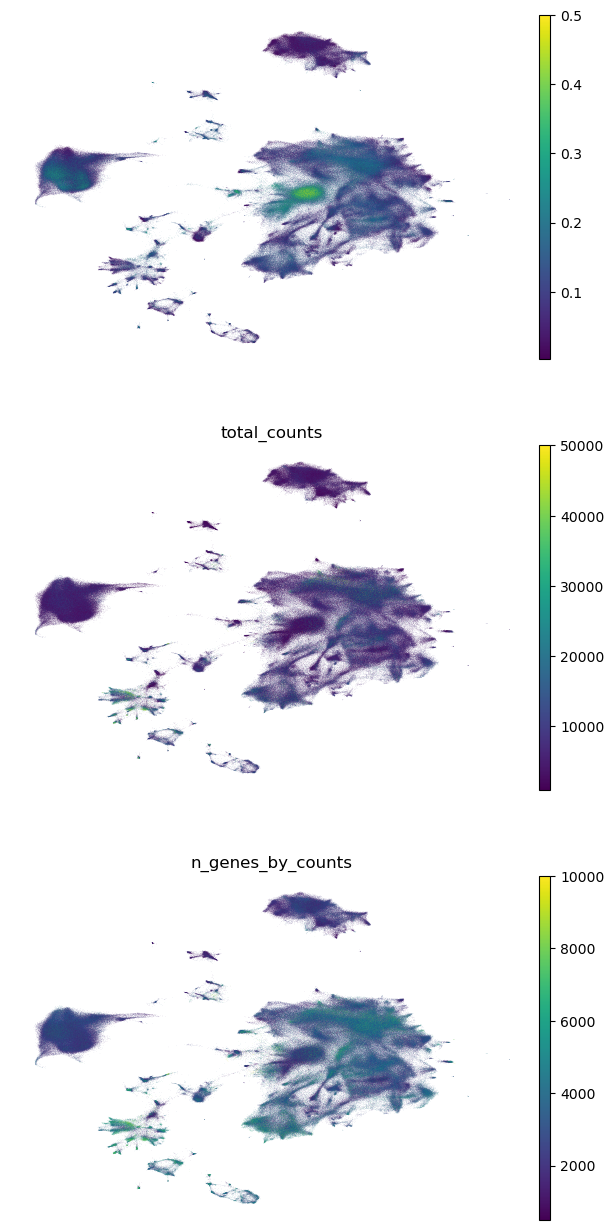

In [ ]:
sc.pl.umap(adata, color=['doublet_scores', 'total_counts', 'n_genes_by_counts'], 
               gene_symbols='SYMBOL',
               legend_fontsize=14, title = [''], frameon=False, ncols=1, vmax=[0.5, 50000, 10000])

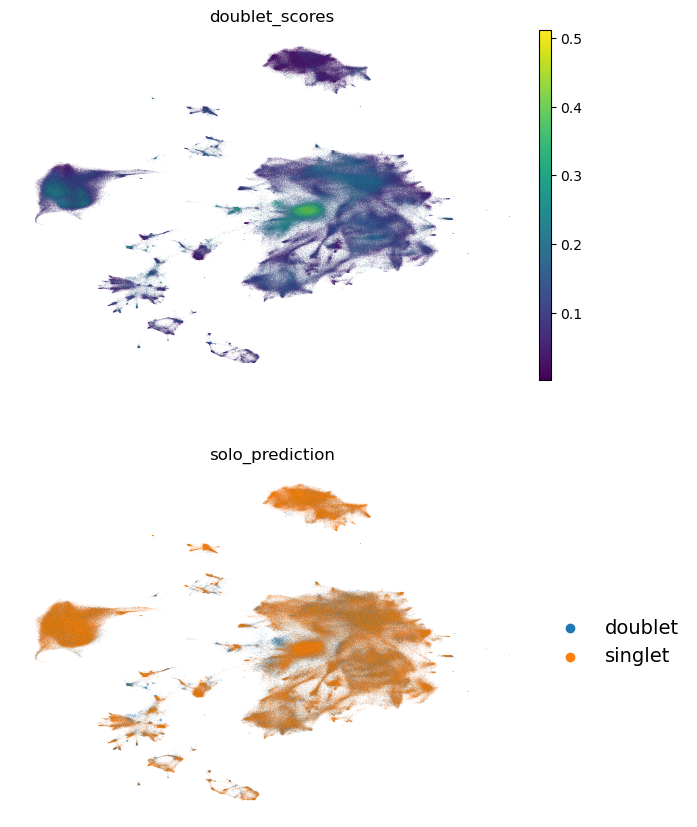

In [ ]:
sc.pl.umap(adata, color=['doublet_scores', 'solo_prediction'], 
               gene_symbols='SYMBOL',
               legend_fontsize=14, frameon=False, ncols=1)

# Coarse annotations

In [ ]:
marker_genes_plot = {
    'Neurons': ['RBFOX3', 'GRIN1', 'GRIN2A', 'RELN'],
    'Oligos': ['MOG', 'MAG', 'OPALIN'], #Oligos
    'OPCs': ['PDGFRA', 'SOX6', 'BCAN'], #OPCs
    'Astros': ['AQP4', 'GFAP', 'SLC17A8'], #Astros
    'Astro activated:':['P2RY14', 'MT3', 'VIM'],
    'Radial glia':['GFAP', 'SLC1A3', 'HES1', 'PAX6', 'SOX2'],
    'Micros': ['CX3CR1', 'AIF1', 'ITGAM', 'TREM2'], #Microglia
    'Endo': ['APOLD1', 'VWF'], #Endo
    'VLMC': ['COLEC12', 'CYP1B1', 'OGN', 'LUM', 'DCN'], #vascular and leptomeningeal cell
    'Peri': ['MUSTN1', 'DLC1', 'ANPEP'],
    'T cells': ['CD3G', 'CD8A'],
    'B cells': ['CD79A']
}

marker_genes_eugene = {
    'Neurons': ['RBFOX3', 'DCX', 'MAP2', 'NCAM1', 'GRIN1', 'GRIN2A', 'FOS'], #Neurons
    'Neurons_G': ["SNAP25", "STMN2", "RBFOX3"],
    'Exc_G': ["SATB2","SLC17A7","SLC17A6", "CAMK2A", 'GRIA1', 'GRIA2'],
    'Inh_G': ["GAD1", "GAD2", "SLC32A1"],
    'Exc': ['SLC17A7', 'SLC17A6', 'LINC00507'], #Exc
    'Inh': ['GAD1', 'GAD2', 'ADARB2', 'LAMP5', 'PVALB', 'SST', 'HTR3A', 'VIP', 'SNCG', 'SV2C', 'CHODL'], #Inh
    'Layers': ['RELN', 'CUX1', 'CUX2', 'RORB', 'FEZF2', 'THEMIS'], #Layer specific
    'Oligos': ['PLP1', 'MBP', 'MOG', 'MAG', 'OPALIN', 'OLIG1', 'OLIG2', 'MYRF', 'FOXO1', 'FOXO4', 'CNP', 'GALC'], #Oligos
    'OPCs': ['PDGFRA', 'SOX6', 'SOX10', 'BCAN', 'MYT1', 'CSPG4'], #OPCs
    'Astros': ['AQP4', 'GFAP', 'POU3F2', 'FGFR3', 'EMX2', 'PAX6', 'SLC17A8', 'SLC1A2', 'SLC1A3', 'ALDH1L1', 'ETNPPL', 'MT1G'], #Astros
    'Astros A1': ['SERPING1', 'GBP2', 'AMIGO2', 'SRGN'], 
    'Astros A2': ['EMP1', 'SLC10A6', 'CD14', 'S100A10', 'CD109'], 
    'Astro Superficial Layers':['CHRDL1', 'APOE', 'EOGT'],
    'Astro Deep Layers':['ID1', 'ID3', 'PHGDH', 'CD44'],
    'Astro activated:':['P2RY14', 'MT3', 'VIM'],
    'Micros': ['TMEM119', 'CX3CR1', 'AIF1', 'ITGAM', 'CD33', 'TREM2'], #Microglia
    'M1 Micros': ['IL1B', 'TNF', 'STAT3', 'IL6', 'IL18'],
    'M2 Micros': ['IL10', 'IL4', 'IL13', 'TGFB1', 'TGFB2', ],
    'DAM Micros': ['TREM2', 'APOE', 'SPP1', 'TYROBP', 'CTSB'],
    'Micro inflam': ['SRGN','CCL3','CCL4','IL1B'],
    'Phagocytosis':['CD163', 'P2RY12', 'LAMP1', 'LAMP2', 'HGSNAT', 'UNC13D', 'CD36', 'DNM2', 'CDC42', 'RAC1'], #CD163 and P2RY12 from 31316211 (microglia specific), rest are lysosome genes from PMC4387238 or phagocytosis GO
    'Endo': ['APOLD1', 'VWF', 'FLT1', 'CLDN5', 'VCAM1', 'EMCN', 
             'PLVAP'], #Endo
    'VLMC': ['PDGFRA', 'COLEC12', 'CYP1B1', 'OGN', 'LUM', 'DCN'], #vascular and leptomeningeal cell
    'Peri': ['MUSTN1', 'DLC1', 'ANPEP'],
    'Messenchymal':['VIM'],
    'T cells': ['CD3G', 'CD4', 'CD8A', 'CD8B', 'FAS'],
    'B cells': ['CD79A']
}

In [ ]:
sc.pl.dotplot(adata, 
              marker_genes_eugene, 
              groupby='leiden_scVI', 
              dendrogram=False, gene_symbols="SYMBOL", 
              standard_scale='var')

In [ ]:
sc.pl.dotplot(adata, marker_genes_plot, groupby='leiden_scVI', 
              dendrogram=False, gene_symbols="SYMBOL", standard_scale='var')

In [ ]:
# Neurons
exc_neurons = (adata.obs['leiden_scVI']=='10') | (adata.obs['leiden_scVI']=='26')
inh_neurons = (adata.obs['leiden_scVI']=='17') | (adata.obs['leiden_scVI']=='18')

# Microglia
microglia = (adata.obs['leiden_scVI']=='2')

# Vasculature, etc. 
endo_vlmc = adata.obs['leiden_scVI']=='23'

# Oligodendrocytes
oligo = (adata.obs['leiden_scVI']=='0') | (adata.obs['leiden_scVI']=='40') 

# Astrocytes
astros = (adata.obs['leiden_scVI']=='19')

# OPC UNCERTAIN
OPC = adata.obs['leiden_scVI']=='16'

# T cells
t_cells = adata.obs['leiden_scVI']=='21'

# B cells
b_cells = adata.obs['leiden_scVI']=='31'

In [ ]:
# manually annotate
adata.obs['coarse_prediction'] = np.where(
    exc_neurons, 'Neurons (Exc)',
    np.where(inh_neurons, 'Neurons (Inh)',
             np.where(microglia, 'Macrophages',
                    np.where(oligo, 'Oligodendrocytes',
                             np.where(astros, 'Astrocytes',
                                  np.where(b_cells, 'B cells',
                                        np.where(OPC, 'OPCs',
                                                 np.where(endo_vlmc, 'Vascular-associated',
                                                          np.where(t_cells, 'Lymphocytes',
                                                                   'Unknown')))))))))

In [ ]:
# generate UMAP
sc.pl.umap(
    adata,
    color=['coarse_prediction'],
    ncols=2,
    size=0.1,
    frameon=False)

In [ ]:
adata.raw.to_adata().write_h5ad('../data/adata/GBM_LEAP_15_05_23_coarse_annos.h5ad')

In [ ]:
adata.obs[['cell_id', 'leiden_scVI']]\
.to_csv('../data/metadata/post_QC_barcodes_2023_05.csv', 
        index=None)